In [1]:
import numpy as np 
import matplotlib.pyplot as plt
import h5py
import pandas as pd


from scipy.stats import norm
import scipy.signal as sig

from scipy.ndimage import convolve1d

In [2]:
with h5py.File("/Users/berenakpinar/lfads-torch/lfads-torch/runs/lfads-torch-example/my_data_module/251103_exampleSingle/lfads_output_bilbo_CHKDLAY_DLPFC_20250325_20ms_TAR_LFADS.h5") as f:
    for k in f.keys():
        print(k)

    train_factors = f["train_factors"][:]
    valid_factors = f["valid_factors"][:]

    valid_encod_data = f["valid_encod_data"][:]
    valid_recon_data = f["valid_recon_data"][:]
    train_output_params = f["train_output_params"][:]

    valid_ic_mean = f["valid_ic_mean"][:]

    train_encod_data = f["train_encod_data"][:]
    train_recon_data = f["train_recon_data"][:]



train_co_means
train_co_stds
train_con_states
train_encod_data
train_factors
train_gen_init
train_gen_inputs
train_gen_states
train_ic_mean
train_ic_std
train_inds
train_output_params
train_recon_data
valid_co_means
valid_co_stds
valid_con_states
valid_encod_data
valid_factors
valid_gen_init
valid_gen_inputs
valid_gen_states
valid_ic_mean
valid_ic_std
valid_inds
valid_output_params
valid_recon_data


In [3]:
train_output_params.shape

(516, 92, 178)

NameError: name 'rates' is not defined

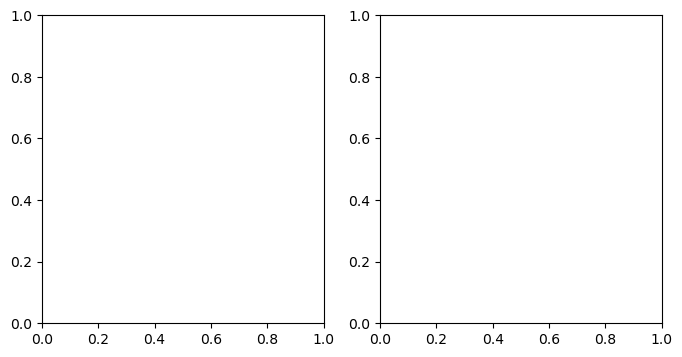

In [4]:
uoc = np.random.choice(np.arange(178))
toc = np.random.choice(np.arange(516))


fig,ax = plt.subplots(1,2, figsize =(8,4))
ax[0].plot(rates[toc, :, uoc], label="original") #exact spikes
ax[1].plot(train_output_params[toc, :, uoc], label="reconstructed") # firing rates 
ax[0].legend()
ax[1].legend()
fig.suptitle(f"Trial {toc}, unit {uoc}")

In [ ]:
def smooth_spikes(spike_trains, bin_size=0.001, kernel_size=0.200, kernel_type='gaussian', scale_kernel=False, sigma=None, method='fft', axis=-1):
    """
    Apply smoothing kernel to spike train data using convolution.
    
    Args:
        spike_trains (array): Input spike train data to be smoothed
        bin_size (float, optional): Time bin size in seconds. Defaults to 0.001.
        kernel_size (float, optional): Size of smoothing kernel in seconds. Defaults to 0.200.
        kernel_type (str, optional): Type of kernel ('gaussian' or 'boxcar'). Defaults to 'gaussian'.
        scale_kernel (str or False, optional): Kernel scaling method ('hz', 'fs', or False). 
            Defaults to False.
        sigma (float, optional): Standard deviation for Gaussian kernel. If None, uses 
            kernel_size/8. Defaults to None.
        method (str, optional): Convolution method ('fft' or 'reflect'). Defaults to 'fft'.
        axis (int, optional): Axis along which to apply smoothing. Defaults to -1.
    
    Returns:
        array: Smoothed spike train data with same shape as input
        
    Note:
        FFT method uses reflect padding to avoid edge artifacts. Gaussian kernel
        sigma defaults to kernel_size/8 if not specified.

    TO-DO:
        Adjust more for different bin sizes?
    """
    cend = kernel_size / 2
    cstart = -cend
    kernel_time = np.arange(cstart, cend, bin_size) # millisecond time step
    if kernel_type == 'gaussian':
        if sigma == None:
            sigma = kernel_size / 8
        kernel = norm.pdf(kernel_time, 0, sigma)
        if scale_kernel == 'hz':
            kernel *= (sigma / (2 * kernel_size))
        elif scale_kernel == 'fs':
            kernel *= bin_size
    elif kernel_type == 'boxcar':
        kernel = np.ones(kernel_time.size)

    if method == 'fft':
        spktrns_mvax = np.moveaxis(spike_trains, axis, -1)
        original_shape = spktrns_mvax.shape

        # reshape for batch
        spktrns_2d = spktrns_mvax.reshape(-1, spktrns_mvax.shape[-1])
        result = np.zeros_like(spktrns_2d)

        # process each row
        pad_width = len(kernel) - 1
        start = len(kernel) - 1
        end = start + len(spktrns_2d[0])
        
        for i in range(spktrns_2d.shape[0]):
            padded_input = np.pad(spktrns_2d[i], pad_width, mode='reflect')
            result[i] = sig.fftconvolve(padded_input, kernel, mode='same')[start:end]
        
        # reshape back, move axis
        result = result.reshape(original_shape)
        smoothed_spikes = np.moveaxis(result, -1, axis)
    elif method == 'reflect':
        smoothed_spikes = convolve1d(spike_trains.astype(float), kernel, axis=axis, mode=method)

    return smoothed_spikes

In [ ]:
rates = smooth_spikes(train_encod_data, bin_size = 0.010, scale_kernel='fs', axis = -2)

In [ ]:
train_factors.shape # the train factors are the dynamical system of the RNN in the 40 dimensions we have constrained it to under the 92 timestamps for 516 trials 

(516, 92, 40)

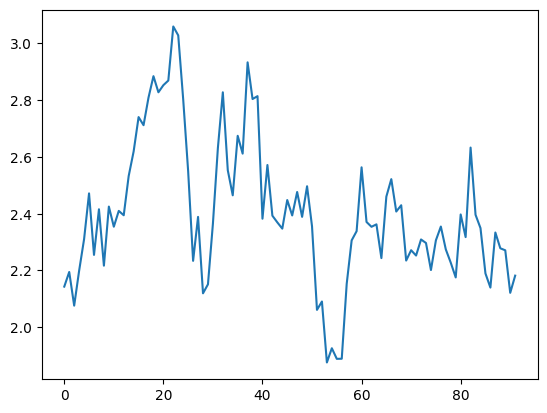

In [ ]:
plt.plot(train_factors[50,:,39])

In [ ]:
# Correlation between latent factors and neural output params
# Combine train + valid to use all available trials
factors_all = np.concatenate([train_factors, valid_factors], axis=0)               # (K, T, L)
output_all = np.concatenate([train_output_params, valid_output_params], axis=0)    # (K, T, N)

# Flatten trial and time dimensions so each sample is one trial-time bin
X = factors_all.reshape(-1, factors_all.shape[-1])
Y = output_all.reshape(-1, output_all.shape[-1])

# Z-score each latent factor and neuron output
X = X - X.mean(axis=0, keepdims=True)
Y = Y - Y.mean(axis=0, keepdims=True)
X = X / (X.std(axis=0, ddof=1, keepdims=True) + 1e-12)
Y = Y / (Y.std(axis=0, ddof=1, keepdims=True) + 1e-12)

# Pearson correlation matrix: latent factor x neuron
corr = (X.T @ Y) / (X.shape[0] - 1)

# Plot heatmap + per-factor summary
max_neurons_to_show = 60
n_show = min(max_neurons_to_show, corr.shape[1])

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
im = ax[0].imshow(corr[:, :n_show], aspect='auto', cmap='coolwarm', vmin=-1, vmax=1)
ax[0].set_title(f'Latent Factors vs Neural Output Correlation (first {n_show} neurons)')
ax[0].set_xlabel('Neuron index')
ax[0].set_ylabel('Latent factor index')
fig.colorbar(im, ax=ax[0], label='Pearson r', fraction=0.046, pad=0.04)

mean_abs_corr = np.mean(np.abs(corr), axis=1)
ax[1].bar(np.arange(corr.shape[0]), mean_abs_corr)
ax[1].set_title('Mean |correlation| per latent factor')
ax[1].set_xlabel('Latent factor index')
ax[1].set_ylabel('Mean |r| across neurons')

fig.tight_layout()
plt.show()

# Optional: save figure
# fig.savefig('factor_neural_output_correlation.png', dpi=150, bbox_inches='tight')